<a href="https://colab.research.google.com/github/leandroclv/python_analise_dados_udemy/blob/main/analise_de_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 100)

In [ ]:
df = pd.read_csv('dados_enem_2021_BA.csv')

No Pandas podemos carregar dados diferentes formatos. Os principais são:

- CSV
- Excel
- SQL

Usando Pyspark um formato muito utilizado é o parquet. Veremos este ponto mais adiante.

De igual modo podemos escrever os arquivos em diferentes formatos(output).

Na prática o formato de dados que iremos trabalhar vai depender muito da origem dos dados, da estrutura da empresa que estaremos trabalhando, etc.

Microdados ENEM

Grupos de variáveis

  - Dados do participante
  - Dados da escola
  - Dados do local de aplicação da prova
  - Dados da prova objetiva
  - Dados da redação
  - Dados do questionário socioeconômico

Hipóteses levantadas

- Padrões especiais afetam o desempenho escolar?
- Características municipais afetam o desempenho escolar?
- Renda familiar pode afetar a nota dos alunos?
- Há diferença de desempenho entre escolas públicas e privadas?
- Qual matéria tem maior nota naquela região?

Inspeção de dados

In [ ]:
#Leitura das 5 primeiras linhas
df.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,210051128744,2021,4,F,1,3,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927200,Ruy Barbosa,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,507.6,539.2,494.6,413.3,BAEDEBDECCEAEDDCBDEDAEECEEEDBDECBDCECBCCDABED,EEEBAABCBCDBEAEBEACEDDEDECACBDBCDACECDAECBCBD,99999ACAEEEEBDEACDACDEABCEABBDEDBAEEBDEEACDBAC...,BACEACDACBAAAEDCECABBACDCDBBA.CEABCDADADBECBE,1,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,80.0,120.0,80.0,80.0,20.0,380.0
1,210054173438,2021,5,F,1,2,1,2,0,2,1.0,0,2927408.0,Salvador,29.0,BA,1.0,1.0,1.0,2927408,Salvador,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,210052118573,2021,3,F,1,3,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2903201,Barreiras,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,439.6,437.7,455.9,446.2,BCEDEACAEDCEDCBDDCCAADABADDEBEECBACDCCABBDCCA,AAEADCDCAAADCBBBAABBEAEDABCDAACDDCBDAAABAABBB,EDBEC99999DDAAEBBDCDBBAABDECAADAEACCDABCEABABE...,EBBEBDCCDDCDCBADABBBCCEABDADCBCCACBDACDCDADCE,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,80.0,120.0,80.0,100.0,80.0,460.0
3,210052350230,2021,10,F,1,2,1,1,8,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2928802,Santo Estêvão,29,BA,1,1,1,1,911.0,880.0,890.0,902.0,548.1,619.5,676.3,386.6,CCAECCADEAADDEDDEECEDDEADDDCACDEDCDCDEADBEDDE,DBBEADDCABABCECEAEBEAEDCBCAEABEEDEBBEAABCBDCD,ABCCA99999DDCACDCACABBEAAEBDAEEBDEEAADACEEDDDB...,CAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,0,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,120.0,120.0,100.0,120.0,120.0,580.0
4,210053156861,2021,9,M,1,2,1,1,5,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2910800,Feira de Santana,29,BA,1,1,1,1,1014.0,1000.0,1004.0,1010.0,465.2,613.1,522.1,579.6,CDCCBDBBDCBACEBDACBCACADBCBECCEBCDDEBDACEECCD,CCBAADECCBACBECCBEADAEBEACBEBBEADEBBABDACDEBC,BADCE99999DABAABBABBBCEDBDCDABEABCBBDCACBABAAA...,CCBACBBCCCCEDDDDCBCCDCACCCBBBDDDBCBADDBCABACA,0,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,100.0,120.0,100.0,120.0,100.0,540.0


In [ ]:
#Leitura das 5 últimas linhas
df.tail()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
266189,210051432069,2021,12,M,1,3,1,1,0,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2900702,Alagoinhas,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266190,210051106175,2021,14,M,2,2,1,1,0,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2918407,Juazeiro,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266191,210051995005,2021,11,M,0,2,1,1,12,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266192,210053234415,2021,12,M,2,2,1,1,15,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266193,210054027870,2021,5,F,1,2,1,1,2,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nota: os comandos `df.head()` e `df.tail()` são úteis para inspecionar e compreender o dataset

In [ ]:
#Quantidade de linhas vs Quantidade de colunas
df.shape

(266194, 51)

In [ ]:
#Sumário do dataset com número de valores não nulos, dtypes de cada coluna, memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266194 entries, 0 to 266193
Data columns (total 51 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   NU_INSCRICAO            266194 non-null  int64  
 1   NU_ANO                  266194 non-null  int64  
 2   TP_FAIXA_ETARIA         266194 non-null  int64  
 3   TP_SEXO                 266194 non-null  object 
 4   TP_ESTADO_CIVIL         266194 non-null  int64  
 5   TP_COR_RACA             266194 non-null  int64  
 6   TP_NACIONALIDADE        266194 non-null  int64  
 7   TP_ST_CONCLUSAO         266194 non-null  int64  
 8   TP_ANO_CONCLUIU         266194 non-null  int64  
 9   TP_ESCOLA               266194 non-null  int64  
 10  TP_ENSINO               84388 non-null   float64
 11  IN_TREINEIRO            266194 non-null  int64  
 12  CO_MUNICIPIO_ESC        47820 non-null   float64
 13  NO_MUNICIPIO_ESC        47820 non-null   object 
 14  CO_UF_ESC           

In [ ]:
#Nomes das colunas
df.columns

Index(['NU_INSCRICAO', 'NU_ANO', 'TP_FAIXA_ETARIA', 'TP_SEXO',
       'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO',
       'TP_ANO_CONCLUIU', 'TP_ESCOLA', 'TP_ENSINO', 'IN_TREINEIRO',
       'CO_MUNICIPIO_ESC', 'NO_MUNICIPIO_ESC', 'CO_UF_ESC', 'SG_UF_ESC',
       'TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC',
       'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA',
       'SG_UF_PROVA', 'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC',
       'TP_PRESENCA_MT', 'CO_PROVA_CN', 'CO_PROVA_CH', 'CO_PROVA_LC',
       'CO_PROVA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT',
       'TX_RESPOSTAS_CN', 'TX_RESPOSTAS_CH', 'TX_RESPOSTAS_LC',
       'TX_RESPOSTAS_MT', 'TP_LINGUA', 'TX_GABARITO_CN', 'TX_GABARITO_CH',
       'TX_GABARITO_LC', 'TX_GABARITO_MT', 'TP_STATUS_REDACAO',
       'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4',
       'NU_NOTA_COMP5', 'NU_NOTA_REDACAO'],
      dtype='object')

In [ ]:
#Verificar missing (dados ausentes)
((df.isna().sum() / df.shape[0]) * 100).round(2).sort_values(ascending=False)

,0
TP_DEPENDENCIA_ADM_ESC,82.04
TP_SIT_FUNC_ESC,82.04
SG_UF_ESC,82.04
NO_MUNICIPIO_ESC,82.04
CO_UF_ESC,82.04
CO_MUNICIPIO_ESC,82.04
TP_LOCALIZACAO_ESC,82.04
TP_ENSINO,68.30
CO_PROVA_MT,34.12
NU_NOTA_MT,34.12


In [ ]:
#Sumário estatístico dos dados
#25%: primeiro quartil
#50%: segundo quartil (mediana)
#75%: terceiro quartil
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
NU_INSCRICAO,266194.0,2.100527e+11,981957.687860,2.100510e+11,2.100519e+11,2.100527e+11,2.100536e+11,2.100545e+11
NU_ANO,266194.0,2.021000e+03,0.000000,2.021000e+03,2.021000e+03,2.021000e+03,2.021000e+03,2.021000e+03
TP_FAIXA_ETARIA,266194.0,5.710166e+00,3.878161,1.000000e+00,3.000000e+00,4.000000e+00,8.000000e+00,2.000000e+01
TP_ESTADO_CIVIL,266194.0,1.048991e+00,0.411030,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00
TP_COR_RACA,266194.0,2.301832e+00,0.907761,0.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,5.000000e+00
TP_NACIONALIDADE,266194.0,1.029787e+00,0.194507,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00
TP_ST_CONCLUSAO,266194.0,1.595810e+00,0.719902,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00
TP_ANO_CONCLUIU,266194.0,2.846845e+00,4.468500,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,1.500000e+01
TP_ESCOLA,266194.0,1.379663e+00,0.570947,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00
TP_ENSINO,84388.0,1.013272e+00,0.114438,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00


In [ ]:
df.index

RangeIndex(start=0, stop=266194, step=1)

In [ ]:
#Quantidade de valores únicos por coluna
df.nunique().sort_values()

,0
NU_ANO,1
SG_UF_PROVA,1
CO_UF_PROVA,1
TP_SEXO,2
TP_ENSINO,2
TP_LOCALIZACAO_ESC,2
IN_TREINEIRO,2
TP_LINGUA,2
TP_PRESENCA_CN,3
TP_PRESENCA_CH,3


In [ ]:
type(df)

pandas.core.frame.DataFrame

In [ ]:
#Seleciona uma coluna
df.TP_ESCOLA

,TP_ESCOLA
0,2
1,2
2,2
3,1
4,1
...,...
266189,1
266190,1
266191,1
266192,1


In [ ]:
#Distribuição de frequência
df.TP_ESCOLA.value_counts()

,count
TP_ESCOLA,
1,177170
2,76984
3,12040


In [ ]:
#Seleciona uma coluna
df['TP_ESCOLA']

,TP_ESCOLA
0,2
1,2
2,2
3,1
4,1
...,...
266189,1
266190,1
266191,1
266192,1


In [ ]:
#Seleciona uma coluna
#.loc[]: seleciona colunas pelo label
#sintaxe: df.loc[linhas:colunas]
df.loc[:, 'TP_SEXO']

,TP_SEXO
0,F
1,F
2,F
3,F
4,M
...,...
266189,M
266190,M
266191,M
266192,M


In [ ]:
#Selecão multiplas
df[['TP_SEXO', 'TP_ESCOLA']]

,TP_SEXO,TP_ESCOLA
0,F,2
1,F,2
2,F,2
3,F,1
4,M,1
...,...,...
266189,M,1
266190,M,1
266191,M,1
266192,M,1


In [ ]:
#Seleciona múltiplas colunas com .loc
df.loc[:,['TP_SEXO', 'TP_ESCOLA']]

,TP_SEXO,TP_ESCOLA
0,F,2
1,F,2
2,F,2
3,F,1
4,M,1
...,...,...
266189,M,1
266190,M,1
266191,M,1
266192,M,1


In [ ]:
#.iloc[]: Seleciona colunas pela posição
df.iloc[0:5, 0]

,NU_INSCRICAO
0,210051128744
1,210054173438
2,210052118573
3,210052350230
4,210053156861


Com a função `.select_dtypes()` podemos selecionar colunas de acordo com seu dtype (int, float, bool, etc.). Em várias situações isso pode ser útil, dentre outras coisas para aplicarmos rotinas específicas deacordo com o dtype ou ainda separar as colunas em qualitativas e quantitativas

In [ ]:
#Seleciona colunas numéricas
df.select_dtypes(include=[int, float])

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,CO_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,CO_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,210051128744,2021,4,1,3,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,2927200,29,1,1,1,1,909.0,881.0,892.0,899.0,507.6,539.2,494.6,413.3,1,1.0,80.0,120.0,80.0,80.0,20.0,380.0
1,210054173438,2021,5,1,2,1,2,0,2,1.0,0,2927408.0,29.0,1.0,1.0,1.0,2927408,29,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,210052118573,2021,3,1,3,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,2903201,29,1,1,1,1,912.0,882.0,891.0,901.0,439.6,437.7,455.9,446.2,0,1.0,80.0,120.0,80.0,100.0,80.0,460.0
3,210052350230,2021,10,1,2,1,1,8,1,NaN,0,NaN,NaN,NaN,NaN,NaN,2928802,29,1,1,1,1,911.0,880.0,890.0,902.0,548.1,619.5,676.3,386.6,0,1.0,120.0,120.0,100.0,120.0,120.0,580.0
4,210053156861,2021,9,1,2,1,1,5,1,NaN,0,NaN,NaN,NaN,NaN,NaN,2910800,29,1,1,1,1,1014.0,1000.0,1004.0,1010.0,465.2,613.1,522.1,579.6,0,1.0,100.0,120.0,100.0,120.0,100.0,540.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266189,210051432069,2021,12,1,3,1,1,0,1,NaN,0,NaN,NaN,NaN,NaN,NaN,2900702,29,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266190,210051106175,2021,14,2,2,1,1,0,1,NaN,0,NaN,NaN,NaN,NaN,NaN,2918407,29,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266191,210051995005,2021,11,0,2,1,1,12,1,NaN,0,NaN,NaN,NaN,NaN,NaN,2927408,29,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266192,210053234415,2021,12,2,2,1,1,15,1,NaN,0,NaN,NaN,NaN,NaN,NaN,2927408,29,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Seleciona colunas str
#df.select_dtypes(exclude=[int, float])
df.select_dtypes(include=object)

,TP_SEXO,NO_MUNICIPIO_ESC,SG_UF_ESC,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT
0,F,NaN,NaN,Ruy Barbosa,BA,BAEDEBDECCEAEDDCBDEDAEECEEEDBDECBDCECBCCDABED,EEEBAABCBCDBEAEBEACEDDEDECACBDBCDACECDAECBCBD,99999ACAEEEEBDEACDACDEABCEABBDEDBAEEBDEEACDBAC...,BACEACDACBAAAEDCECABBACDCDBBA.CEABCDADADBECBE,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB
1,F,Salvador,BA,Salvador,BA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F,NaN,NaN,Barreiras,BA,BCEDEACAEDCEDCBDDCCAADABADDEBEECBACDCCABBDCCA,AAEADCDCAAADCBBBAABBEAEDABCDAACDDCBDAAABAABBB,EDBEC99999DDAAEBBDCDBBAABDECAADAEACCDABCEABABE...,EBBEBDCCDDCDCBADABBBCCEABDADCBCCACBDACDCDADCE,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE
3,F,NaN,NaN,Santo Estêvão,BA,CCAECCADEAADDEDDEECEDDEADDDCACDEDCDCDEADBEDDE,DBBEADDCABABCECEAEBEAEDCBCAEABEEDEBBEAABCBDCD,ABCCA99999DDCACDCACABBEAAEBDAEEBDEEAADACEEDDDB...,CAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA
4,M,NaN,NaN,Feira de Santana,BA,CDCCBDBBDCBACEBDACBCACADBCBECCEBCDDEBDACEECCD,CCBAADECCBACBECCBEADAEBEACBEBBEADEBBABDACDEBC,BADCE99999DABAABBABBBCEDBDCDABEABCBBDCACBABAAA...,CCBACBBCCCCEDDDDCBCCDCACCCBBBDDDBCBADDBCABACA,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
266189,M,NaN,NaN,Alagoinhas,BA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266190,M,NaN,NaN,Juazeiro,BA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266191,M,NaN,NaN,Salvador,BA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266192,M,NaN,NaN,Salvador,BA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cat_cols = df.select_dtypes(include=object).columns.tolist()
cat_cols

['TP_SEXO',
 'NO_MUNICIPIO_ESC',
 'SG_UF_ESC',
 'NO_MUNICIPIO_PROVA',
 'SG_UF_PROVA',
 'TX_RESPOSTAS_CN',
 'TX_RESPOSTAS_CH',
 'TX_RESPOSTAS_LC',
 'TX_RESPOSTAS_MT',
 'TX_GABARITO_CN',
 'TX_GABARITO_CH',
 'TX_GABARITO_LC',
 'TX_GABARITO_MT']

In [ ]:
num_cols = df.select_dtypes(include=[int, float]).columns.tolist()
num_cols

['NU_INSCRICAO',
 'NU_ANO',
 'TP_FAIXA_ETARIA',
 'TP_ESTADO_CIVIL',
 'TP_COR_RACA',
 'TP_NACIONALIDADE',
 'TP_ST_CONCLUSAO',
 'TP_ANO_CONCLUIU',
 'TP_ESCOLA',
 'TP_ENSINO',
 'IN_TREINEIRO',
 'CO_MUNICIPIO_ESC',
 'CO_UF_ESC',
 'TP_DEPENDENCIA_ADM_ESC',
 'TP_LOCALIZACAO_ESC',
 'TP_SIT_FUNC_ESC',
 'CO_MUNICIPIO_PROVA',
 'CO_UF_PROVA',
 'TP_PRESENCA_CN',
 'TP_PRESENCA_CH',
 'TP_PRESENCA_LC',
 'TP_PRESENCA_MT',
 'CO_PROVA_CN',
 'CO_PROVA_CH',
 'CO_PROVA_LC',
 'CO_PROVA_MT',
 'NU_NOTA_CN',
 'NU_NOTA_CH',
 'NU_NOTA_LC',
 'NU_NOTA_MT',
 'TP_LINGUA',
 'TP_STATUS_REDACAO',
 'NU_NOTA_COMP1',
 'NU_NOTA_COMP2',
 'NU_NOTA_COMP3',
 'NU_NOTA_COMP4',
 'NU_NOTA_COMP5',
 'NU_NOTA_REDACAO']

Filtro

Existe diferença na nota de matemática entre alunos de escola pública e privada?

In [ ]:
#Alunos colégio público
df.query('TP_ESCOLA == 2').NU_NOTA_MT.agg([np.mean, np.median])

/tmp/ipykernel_3468/3707071764.py:2: FutureWarning: The provided callable <function mean at 0x7a03bf717f60> is currently using Series.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.query('TP_ESCOLA == 2').NU_NOTA_MT.agg([np.mean, np.median])
/tmp/ipykernel_3468/3707071764.py:2: FutureWarning: The provided callable <function median at 0x7a03bf1a7380> is currently using Series.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  df.query('TP_ESCOLA == 2').NU_NOTA_MT.agg([np.mean, np.median])


,NU_NOTA_MT
mean,487.37505
median,468.90000


In [ ]:
#Alunos de escola privada
df.query('TP_ESCOLA == 3').NU_NOTA_MT.agg([np.mean, np.median])

/tmp/ipykernel_3468/2854653440.py:2: FutureWarning: The provided callable <function mean at 0x7a03bf717f60> is currently using Series.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.query('TP_ESCOLA == 3').NU_NOTA_MT.agg([np.mean, np.median])
/tmp/ipykernel_3468/2854653440.py:2: FutureWarning: The provided callable <function median at 0x7a03bf1a7380> is currently using Series.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  df.query('TP_ESCOLA == 3').NU_NOTA_MT.agg([np.mean, np.median])


,NU_NOTA_MT
mean,579.8339
median,581.6000


In [ ]:
#Validando a nossa consulta
#.unique(): retorna os valores únicos de uma determinada coluna
df.query('TP_SEXO == "M"')['TP_SEXO'].unique()

array(['M'], dtype=object)

In [ ]:
#1 condição
df.query('TP_SEXO == "M"').sample(5)

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
103064,210051424502,2021,2,M,1,1,1,2,0,2,1.0,0,2910701.0,Euclides da Cunha,29.0,BA,1.0,1.0,1.0,2910701,Euclides da Cunha,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,521.6,615.5,558.8,656.7,ABADCBBABECABDCEABDAADEEAACADABDECECDBBCEEBBE,BEECDADDCDEBEBBAEBCABDECCCEBDECAEAABBAABADECB,CAADC99999BDCDEADCBEAEAACBBBDAEDDCBACDBDEAEAAB...,DDBDACDCACDEBCBCDDADBDACEABCCECBCCDCECEBAAAEB,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,1.0,160.0,200.0,180.0,180.0,200.0,920.0
198468,210053635270,2021,4,M,1,3,1,2,0,2,1.0,0,2919504.0,Livramento de Nossa Senhora,29.0,BA,2.0,1.0,1.0,2919504,Livramento de Nossa Senhora,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,412.6,428.6,437.2,429.4,DBDCDCCDCADADEABEDBDCCCDBBEABAABECCDEBDDDAADB,DACBDEABBECCADBBECEEDBBCCAEAEDEABAAACBDCCBECB,CABCC99999DECBEADCDEADABCDADDCBCBECAECCBACAEBE...,EACDCDCBCDBBCBBBDABDCAECABBCBCDDABCDBADACDBDA,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,1.0,120.0,120.0,80.0,120.0,120.0,560.0
187613,210052165871,2021,2,M,1,1,1,2,0,2,1.0,0,2901205.0,Anagé,29.0,BA,2.0,1.0,1.0,2933307,Vitória da Conquista,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,398.3,361.6,400.2,373.3,ECDAABBBCBDEDCAADDBCEABCABECADCBADBEECABCEDBA,BADADBEEABBDBECCBCA*DCEBADEBDADAECBCBEACBDADE,99999AEDBBEDAACDBEBCBDDACEDCBADCAEBEEDABDCAECD...,ADBECBEACBECDBABCDEACBDABECBDEDBDCAEBDBCEBDAC,1,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,3.0,0.0,0.0,0.0,0.0,0.0,0.0
137477,210053622699,2021,13,M,1,3,1,1,15,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2910800,Feira de Santana,29,BA,1,1,1,1,911.0,880.0,890.0,902.0,560.4,608.4,519.1,490.9,CCEE*EBEEEEEEEECAEBEBBDABBEEBAADBCDABEEEBEBBA,CBAAAEACBDABDECDEABBACCEACAEBBEEDEBBBBABEBBAB,99999ACAEECBCACDDACCBBDEDADDABEBDAEBBDDCCDDDBD...,*EBACCACCBDACCACECCCCCECCCCCCC.DCCCCCDCCCCCCC,1,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,100.0,120.0,100.0,100.0,120.0,540.0
138526,210051584012,2021,6,M,1,5,1,1,4,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2924009,Paulo Afonso,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,561.8,537.5,491.7,594.5,ABEECCCDAAECCBDABBBDABCEDDACCBEBECDDEDCCEBDAE,BCDCDCBACDDBABEABDBBBEECCDECAACBEACDABDBA.DAA,BCDAC99999BDACEADBBEDEBDECBBAEEDCADACBBCBAEDDA...,BECABDDCDECBDECEDCABECCDBAEBCEACABECCEECDAAEE,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,1.0,120.0,160.0,120.0,160.0,200.0,760.0


In [ ]:
#VAlidando a nossa consulta
#.unique(): retorna os valores únicos de uma determinada coluna
df.query('TP_SEXO == "M"')['TP_SEXO'].unique()

array(['M'], dtype=object)

Agora vamos retornar um subset com os alunos do sexo Masculino que sejam treinados. Neste caso, usaremos o operador & (and).

In [ ]:
df.query("(TP_SEXO == 'M')&(IN_TREINEIRO == 1)").sample(5)

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
153050,210053597357,2021,1,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,461.7,612.3,530.7,488.4,DCADADDAACDBAECAEDCCCACDEEADEBECBCECCCCACDABA,BBECEAEABADBEADCBAEEDDABABBABCAAAEBCBBEECBBBB,ABEEA99999AABBDACECDAADBCEAADEBBBEAACEEABCAAAC...,DBAEEBCBACBADEEADBDEAEACECBDBCCCBABABACADBECB,0,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,100.0,120.0,100.0,100.0,120.0,540.0
127743,210053076663,2021,4,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,408.2,410.1,442.5,478.7,CBECDDABBEBEDBCEBCCDADABDCDADDCAADBEBDAACBECB,AEBECCABDCBDACCCBDBCEACBBBDBDAACADBDEECACEBBC,AACBD99999BDDADDACACACBDAEDBD*BDBEAEACDADACDDA...,CAECEBDABDACAEBAACDBCEABDCEAEBBDCADEBBECADCAC,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,80.0,120.0,80.0,80.0,40.0,400.0
114514,210053065664,2021,1,M,1,1,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
132136,210053688996,2021,2,M,1,1,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2933307,Vitória da Conquista,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,537.2,586.1,492.3,627.0,DABABBABCECADDEBDDEACDCDAAACEEABDABBCCCBEADCE,DAABAACBEACBAEBCECBBADEDBBAECBCDAEDABABCCAECA,ACBAC99999DCBBCCABAABDEDEBDCBBDADDCCDACEEBAECC...,BCCDEABEDBEBDEECEBECDDBDCCBCCBEACDBCDBEDBCDDE,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,120.0,200.0,140.0,120.0,120.0,700.0
207717,210053329296,2021,1,M,1,1,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2910727,Eunápolis,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Agora vamos retornar um subset com os alunos do sexo Masculino que sejam treinados. Neste caso, usaremos o operador | (or).

In [ ]:
df.query("(TP_SEXO == 'M')|(IN_TREINEIRO == 1)").sample(5)

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
17330,210051509426,2021,10,M,1,2,1,1,2,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,451.2,425.2,525.9,584.5,BBCDCCACDCAACCAEDDEAACCEDADACCEAEDBBCCBAAEDCA,ADBEDACAADBEAEAAEDEDDBABCACABCAECEBBCAEBDAAEC,CABAB99999EDADCADEBDDEBDCADBBEBEAACAECBDBADAEB...,DBBDDACEADBDEDACBDACDAEDCEECCEACAAECBCEBCABBD,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,1.0,100.0,120.0,80.0,100.0,0.0,400.0
203823,210051102999,2021,5,M,1,3,1,1,3,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2905701,Camaçari,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
198711,210054196482,2021,2,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2914703,Itaberaba,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,483.9,642.4,602.2,488.3,DBDECCCDDEDAAEECDCDDCECEEABBACEAEEDEECABDBDEE,BADCCACAEDDBEDBADABABEECCAADBEAAAACABABAAEECB,99999CAEAABDCDEADCBABDDDDEBBEAEDBCEADCAADCAAED...,DEBACCBEDCBBCABADBBDAAEBEADDBBBBCAACEBABADACC,1,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,1.0,120.0,100.0,100.0,120.0,120.0,560.0
111523,210051058494,2021,3,M,1,3,1,2,0,2,1.0,0,2906501.0,Candeias,29.0,BA,2.0,1.0,1.0,2906501,Candeias,29,BA,1,1,1,1,911.0,880.0,890.0,902.0,443.0,446.4,417.6,402.1,CDBDADDEDADAECCCEBBCEEBCCCAEDDADACAEABEEDEDEA,DAABBDEAEACCCDACBEACECBAACEDDDCBDABEBAEACCABD,DAACE99999BADDCBAEDCABEAEDABCBCADBAABDADEABABE...,AACBDEDBEEECBCDCEACCDABDDCAEBCBDBBECECEDCEDDD,0,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,100.0,120.0,120.0,120.0,0.0,460.0
247210,210052377551,2021,3,M,1,2,1,1,0,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2922508,Nazaré,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Criando uma máscara booleana
mask = df.TP_SEXO == 'M'

In [ ]:
df[mask]

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
4,210053156861,2021,9,M,1,2,1,1,5,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2910800,Feira de Santana,29,BA,1,1,1,1,1014.0,1000.0,1004.0,1010.0,465.2,613.1,522.1,579.6,CDCCBDBBDCBACEBDACBCACADBCBECCEBCDDEBDACEECCD,CCBAADECCBACBECCBEADAEBEACBEBBEADEBBABDACDEBC,BADCE99999DABAABBABBBCEDBDCDABEABCBBDCACBABAAA...,CCBACBBCCCCEDDDDCBCCDCACCCBBBDDDBCBADDBCABACA,0,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,100.0,120.0,100.0,120.0,100.0,540.0
5,210053085526,2021,3,M,1,1,1,2,0,2,1.0,0,2932606.0,Urandi,29.0,BA,2.0,1.0,1.0,2932606,Urandi,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,414.6,410.1,386.7,423.0,CBCAEDDBBCBABADAABECACCEBDEABCCAECEECCDBCBDCB,BACDABADEBACEDCACDADBCBDBDBECADBEDAEBDCAEBDCA,BAEAB99999CACBABEBADECADCEDCBCADABDEDBDCABCACB...,EACDCADDDCDBADABACEDEDCECBDCCBEAACEADEAECCCEC,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,1.0,120.0,180.0,140.0,160.0,100.0,700.0
7,210053790986,2021,1,M,1,1,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2907202,Casa Nova,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,590.9,659.7,593.6,586.8,BADCBEEBECDDEABAEDEBCDCCDABBBEBBDDACCCADBEACE,EBBBEADACABBBADEECBAAEDDBBADCDADBCADDEBBCCEAB,ACBAB99999DCEADCADACBDEAEDDABDADCBBBDABCDDDECB...,DDEBEEEDDDCAEEBACBEAADDDCCEDEEBABEECEBEEBCAAC,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,160.0,180.0,160.0,200.0,200.0,900.0
9,210054171092,2021,4,M,1,2,1,1,1,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,210052237624,2021,5,M,1,2,1,2,0,2,1.0,0,2910503.0,Entre Rios,29.0,BA,2.0,1.0,1.0,2910503,Entre Rios,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,594.4,572.8,536.6,469.6,DCADABEEABDAEDABADCABEACABDAEBECBBBDCCCDBCBCD,BEECCABABABBEAEACBADCAEBEDAABAEAEADCCCAAEEBAA,ABBAB99999ADDBAABABCBBBACADAEDBBCCEEEBEAACCDBE...,DABEACCEACAACBBABBBACCAACBBAAECBBCBEBCCCBABBD,0,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,100.0,100.0,80.0,80.0,80.0,440.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266185,210052439300,2021,8,M,1,2,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2900702,Alagoinhas,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266189,210051432069,2021,12,M,1,3,1,1,0,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2900702,Alagoinhas,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266190,210051106175,2021,14,M,2,2,1,1,0,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2918407,Juazeiro,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN

In [ ]:
df.loc[mask].sample(5)

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
147489,210052768008,2021,12,M,2,3,1,1,11,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2910727,Eunápolis,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
237652,210051956361,2021,4,M,1,3,2,2,0,3,1.0,0,2927408.0,Salvador,29.0,BA,4.0,1.0,1.0,2927408,Salvador,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,419.5,404.0,368.9,496.6,DCABDEAEBBDBBACABBCCABDBECACDBACDBDECCCACEABA,EDCBDBACEBEEAABAEBEDADDDBBCAEEBBCEBCAADBCABEB,99999BCAEAABBCCECBDDABABEDBBDBCCECADBDCCCBCAEA...,DCBCEACAECDCBCBCEEACCBADBEEDABCAAABBDAAEDDBAB,1,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,80.0,120.0,80.0,100.0,0.0,380.0
37551,210052884065,2021,3,M,1,3,1,1,1,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2919207,Lauro de Freitas,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,549.8,543.1,521.4,642.9,ECCDCBABABDCBEEBBDCBBEBCDBCAEDACDCDDCCCBCBCBA,ABECCEEBABCBEADACBADEEEBBCADDAADADBDABDDBAABA,99999AADEEDDBBEABACBACDDCBCBDEABBEEDEBEBABCBBE...,EABEBAADCCDECBBCBEDCCADADBABDCBEBBCCDBCDBBDCD,1,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,120.0,120.0,100.0,120.0,140.0,600.0
23805,210053049637,2021,2,M,1,2,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2918001,Jequié,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,422.5,394.0,470.5,538.5,CCEBDBACDDCDAEDABCEECDBEEDEEBCBBADEAEDABBBEAB,AEDBAEDACBBDACCAECDBDAADDEAEBEEECCBADEEDADBCC,EEBAC99999BADBEEDDDDCBEDCDCBEADBCCADDBBBAEAAAD...,DECAEADEBEACCAEBBEAEBDEAADDADBEADCEABBECDADCE,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,4.0,0.0,0.0,0.0,0.0,0.0,0.0
181902,210054210750,2021,3,M,1,1,1,1,1,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2907202,Casa Nova,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.loc[(df.TP_SEXO == 'M') & (df.IN_TREINEIRO == 1)].sample(5)

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
136124,210052828886,2021,1,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2933307,Vitória da Conquista,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,463.3,474.4,491.7,526.5,DCCBADEEABCCBEDABDEECDCCABBDAAEDBBBECCADBECAD,AABACABDBADBDEADAEBBADDDDEADCDDADCAEEBABBACAD,99999ECACAEBDABBBDAABAEABACBDDEAADDCAEACADABAC...,ACEDABEDCBEDBCACBBCABDEBCDACBDDDCDBABBCABBEDB,1,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,100.0,120.0,80.0,120.0,100.0,520.0
99925,210054454603,2021,1,M,1,2,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2930501,Serrinha,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,551.5,612.9,536.2,455.8,DADAEDEBECDCEABBADEDDAEDABABEEEBBAAECD.CBBEAD,ECABEADBEADBBAEAEBBBAAADBBBECEADBCECBEDACAEAB,99999ADAAEEEEEECBDDDBAEABEEADACBDEABDAEEDDDBCA...,BDCBBEEDDEDCDECABEEAAEAACCCDDEAAEEADDBCADBBCA,1,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,120.0,120.0,120.0,120.0,180.0,660.0
263032,210053143053,2021,1,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2932903,Valença,29,BA,0,1,1,0,NaN,1018.0,1027.0,NaN,NaN,383.4,370.2,NaN,NaN,BEABCBACEABDEDEEADEEACECBBCCCACEBCADBEACBBCDB,99999EBCBBAEEEADDAEACCAEBCBCBEACBDACBAABCCEBAD...,NaN,1,NaN,EDAEEDBDBABBCCDEABACBCBACABABABEEBAAEBEDDDBBA,CECADBCEBCEAEDACCBEACBACEBADADDAAAAAEBBDADCABB...,NaN,1.0,120.0,120.0,80.0,120.0,0.0,440.0
142149,210053706732,2021,1,M,1,1,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2914802,Itabuna,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,422.2,549.7,355.0,463.8,ABADBCEBDBBBCECDC.EDECDEEBDBAEADCCADDCAABADCA,BBECCEEBDEDCBEDADDAEEBEDBCADBBABAADABBEECDBCD,AACCE99999DBABCCDDABDBDBCDEAAACCCEADCDAECBDDAB...,EABEBDCBCDBBDEECDBCBDCCBECBCABDCDCADDDBADCBDD,0,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,100.0,120.0,100.0,120.0,80.0,520.0
113586,210052830428,2021,1,M,1,1,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,442.6,531.4,519.6,679.8,BCEACCADDBAABCECEDBDAACEEADBCABDBCCADBEADBCAE,BDCCDAABEBABEADCEDAABCEBCAECDBBBEACCBBCBDEEBC,CAABB99999ACBAEDEEEDCCAACACACADAACBACDBCDACADE...,DACBBDCEAAEBADBDADACBAEDCBDCBEADCBDDCDEAACDAA,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,1.0,140.0,180.0,160.0,160.0,100.0,740.0


Uma forma alternativa:

In [ ]:
condition_1 = df.TP_SEXO == 'M'
condition_2 = df.IN_TREINEIRO == 1
df.loc[(condition_1) & (condition_2)]

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
69,210053707047,2021,1,M,1,1,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2902104,Araci,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,521.7,566.7,569.5,702.3,DDD*CEEDECBBEACBAACABEDCEACEEEABCACCCCBDBEDED,DDEDEBCAEDCCBBBEACABAEEADBABCDABBDECBEBACAEAC,ABACC99999DAEADCBDACDDCACDDACADAAEDCDACDDCDACE...,CCEDEBCCDDCDBEBCCBCAEAABDAEEDCEADDABDBABCDACB,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,160.0,200.0,160.0,200.0,180.0,900.0
113,210051127853,2021,1,M,1,2,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2932903,Valença,29,BA,1,1,1,1,911.0,880.0,890.0,902.0,494.4,408.4,504.1,483.3,CBECBCEBEDBADCEBADABBAACBDBAEBBEDCBDAEBDBEBCE,ECEBADDABBACCCBDADEECACABCACBADCBAEACCCAABBCA,BACBA99999CECACBBACCBBEDAEEBADEBEEBACDACACEACD...,AACBCACDDBABCDCBDADBDCEDDBBDACECBDDCADCECBDCA,0,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,120.0,120.0,120.0,140.0,160.0,660.0
151,210053634740,2021,5,M,1,2,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
155,210052073811,2021,1,M,1,2,2,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2911204,Gandu,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
204,210053593141,2021,2,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,Salvador,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,541.6,646.9,510.6,601.0,AEDDABDEADBDEBCAADDCBBCCDCBADECACCDDCEADBCACA,BCECCAEABABCEAEBAACAEDEBBEBABCBBAEEBBEDECBBBA,DACAC99999ACBDDEBEEBCCBBCEAAADAAADAECDEBADCBAA...,CADEEBDDDCBBCBBBBEDDCDAABDBABBEDCCCDDDDBDBCAC,0,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,140.0,40.0,40.0,140.0,40.0,400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265284,210051161032,2021,1,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2928703,Santo Antônio de Jesus,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
265325,210051362311,2021,2,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2904100,Boquira,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
265359,210051833040,2021,2,M,1,1,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2923605,Paramirim,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
265994,210054130477,2021,4,M,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2924009,Paulo Afonso,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Negação

Podemos usar o operador `~` para negar uma determinada condição:

In [ ]:
df[~(df.NO_MUNICIPIO_PROVA.isin(['Salvador']))]

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,210051128744,2021,4,F,1,3,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927200,Ruy Barbosa,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,507.6,539.2,494.6,413.3,BAEDEBDECCEAEDDCBDEDAEECEEEDBDECBDCECBCCDABED,EEEBAABCBCDBEAEBEACEDDEDECACBDBCDACECDAECBCBD,99999ACAEEEEBDEACDACDEABCEABBDEDBAEEBDEEACDBAC...,BACEACDACBAAAEDCECABBACDCDBBA.CEABCDADADBECBE,1,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,80.0,120.0,80.0,80.0,20.0,380.0
2,210052118573,2021,3,F,1,3,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2903201,Barreiras,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,439.6,437.7,455.9,446.2,BCEDEACAEDCEDCBDDCCAADABADDEBEECBACDCCABBDCCA,AAEADCDCAAADCBBBAABBEAEDABCDAACDDCBDAAABAABBB,EDBEC99999DDAAEBBDCDBBAABDECAADAEACCDABCEABABE...,EBBEBDCCDDCDCBADABBBCCEABDADCBCCACBDACDCDADCE,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,80.0,120.0,80.0,100.0,80.0,460.0
3,210052350230,2021,10,F,1,2,1,1,8,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2928802,Santo Estêvão,29,BA,1,1,1,1,911.0,880.0,890.0,902.0,548.1,619.5,676.3,386.6,CCAECCADEAADDEDDEECEDDEADDDCACDEDCDCDEADBEDDE,DBBEADDCABABCECEAEBEAEDCBCAEABEEDEBBEAABCBDCD,ABCCA99999DDCACDCACABBEAAEBDAEEBDEEAADACEEDDDB...,CAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,0,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,120.0,120.0,100.0,120.0,120.0,580.0
4,210053156861,2021,9,M,1,2,1,1,5,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2910800,Feira de Santana,29,BA,1,1,1,1,1014.0,1000.0,1004.0,1010.0,465.2,613.1,522.1,579.6,CDCCBDBBDCBACEBDACBCACADBCBECCEBCDDEBDACEECCD,CCBAADECCBACBECCBEADAEBEACBEBBEADEBBABDACDEBC,BADCE99999DABAABBABBBCEDBDCDABEABCBBDCACBABAAA...,CCBACBBCCCCEDDDDCBCCDCACCCBBBDDDBCBADDBCABACA,0,CDBBBCABEDEDEAAEBACCCBDABCDCBCBDECDADCDBBEEBB,BBBAAEECBBABEECEBAAEADBCACAEABEDDEBBBADBCBADC,ABBCAEAACADDCACDCADABBBBDEBBACEADCEBDDACEEDDDB...,ECCCABBDBDDDCEDDCABXEEEBABEDCEDCCAEBADBCCECDA,1.0,100.0,120.0,100.0,120.0,100.0,540.0
5,210053085526,2021,3,M,1,1,1,2,0,2,1.0,0,2932606.0,Urandi,29.0,BA,2.0,1.0,1.0,2932606,Urandi,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,414.6,410.1,386.7,423.0,CBCAEDDBBCBABADAABECACCEBDEABCCAECEECCDBCBDCB,BACDABADEBACEDCACDADBCBDBDBECADBEDAEBDCAEBDCA,BAEAB99999CACBABEBADECADCEDCBCADABDEDBDCABCACB...,EACDCADDDCDBADABACEDEDCECBDCCBEAACEADEAECCCEC,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,1.0,120.0,180.0,140.0,160.0,100.0,700.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266185,210052439300,2021,8,M,1,2,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2900702,Alagoinhas,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266186,2100537

Visualização dos dados

In [ ]:
provas = df.columns[(df.columns.str.contains('NOTA')) & (~df.columns.str.contains('COMP'))].tolist()
provas

['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

Utilizando uma sintaxe simples de biblioteca Pandas conseguimos gerar análises gráficas rapidamente. Podemos fazer os seguintes tipos de gráficos:

- Barras
- Pizza
- Linha
- Histograma
- Boxplot
- Densidade
- Área
- Dispersão

<Axes: xlabel='TP_SEXO'>

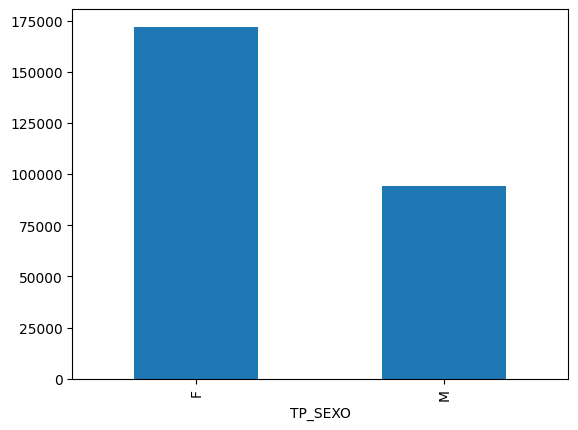

In [ ]:
df.TP_SEXO.value_counts().plot(kind='bar')

Text(0.5, 1.0, 'Tipo de escola dos participantes no ENEM 2021')

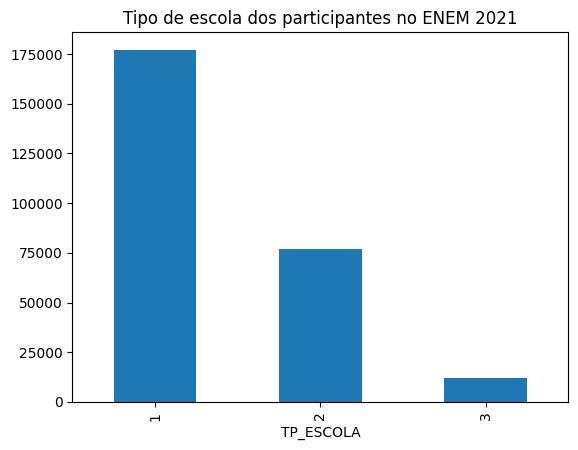

In [ ]:
df.TP_ESCOLA.value_counts().plot(kind='bar')
plt.title('Tipo de escola dos participantes no ENEM 2021')

Melhorando um pouco o plot

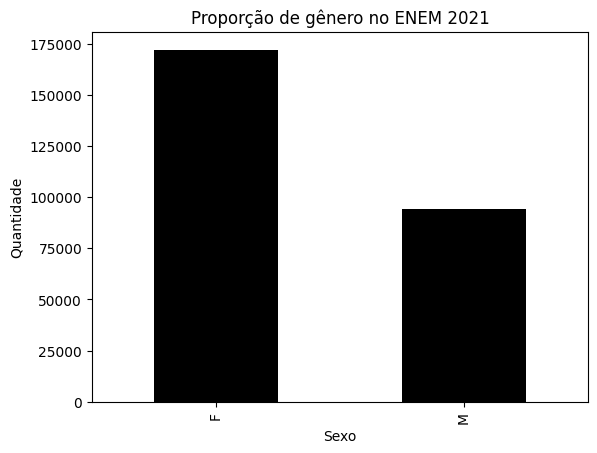

In [ ]:
#Gráfico de barras
df.TP_SEXO.value_counts().plot(kind='bar', color='black')

#Titulo
plt.title('Proporção de gênero no ENEM 2021')

#label dos eixos X e Y
plt.xlabel('Sexo')
plt.ylabel('Quantidade')

plt.show()
#plt.xlabel('Sexo'); plt.ylabel('Quantidade);plt.show()

<Axes: title={'center': 'Municípios baianos com maior quantidade de inscritos no ENEM de 2021'}, xlabel='Quantidade', ylabel='Município'>

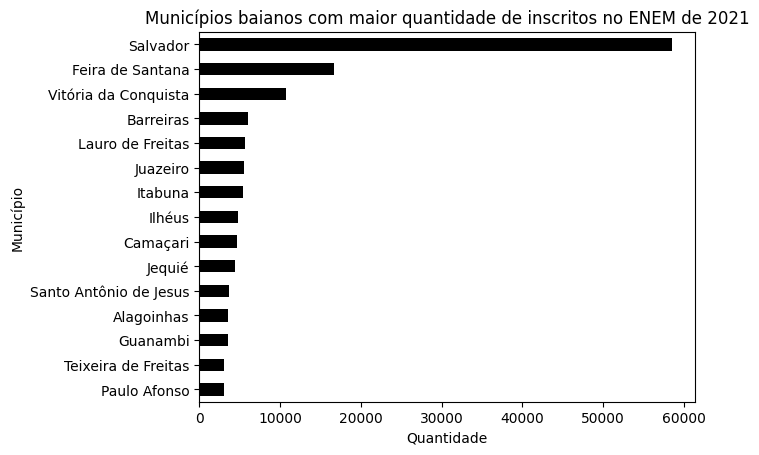

In [ ]:
(df.NO_MUNICIPIO_PROVA
 .value_counts()
 .reset_index()
 .rename(columns = {'NO_MUNICIPIO_PROVA': 'Município', 'count':'Quantidade'})
 .set_index('Município')
 .nlargest(n=15, columns = 'Quantidade')
 .sort_values(by='Quantidade',ascending=True)
 .plot(
        kind='barh',
        color='black',
        legend=False,
        xlabel='Quantidade',
        title = 'Municípios baianos com maior quantidade de inscritos no ENEM de 2021'
    )
 )

<Axes: ylabel='count'>

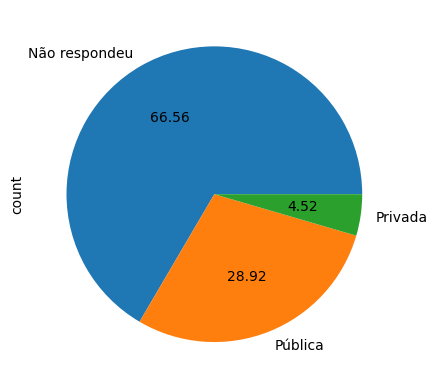

In [ ]:
(
    df.TP_ESCOLA.map({1:'Não respondeu', 2:'Pública', 3:'Privada'})
    .value_counts()
    .plot(
        kind='pie',
        legend=False,
        autopct='%.2f'
    )
)

<Axes: xlabel='NU_NOTA_MT', ylabel='NU_NOTA_CN'>

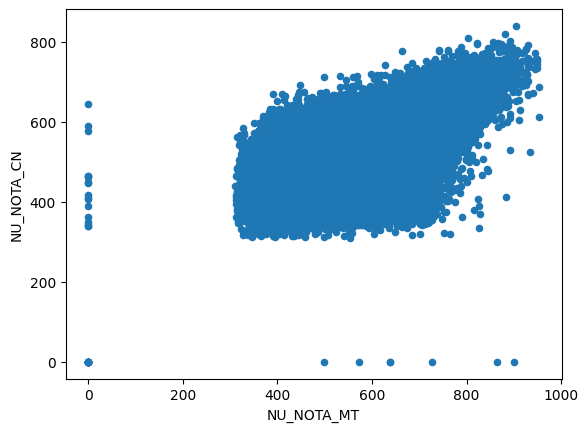

In [ ]:
df.plot(kind='scatter', x='NU_NOTA_MT', y='NU_NOTA_CN')

<Axes: ylabel='Frequency'>

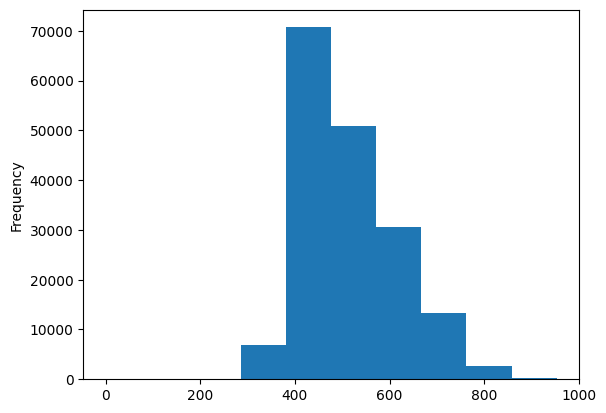

In [ ]:
df.NU_NOTA_MT.plot(kind='hist')

<Axes: >

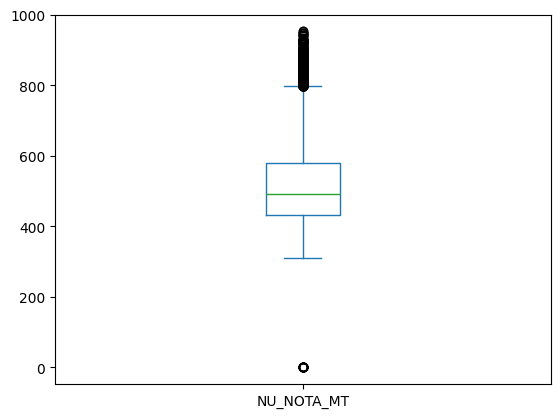

In [ ]:
df.NU_NOTA_MT.plot(kind='box')

<Axes: >

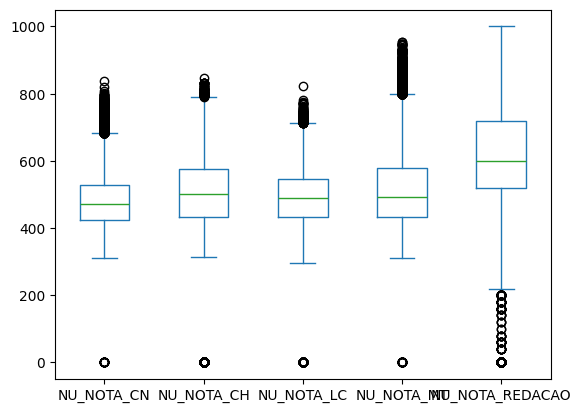

In [ ]:
df[provas].plot(kind='box')

<Axes: ylabel='Density'>

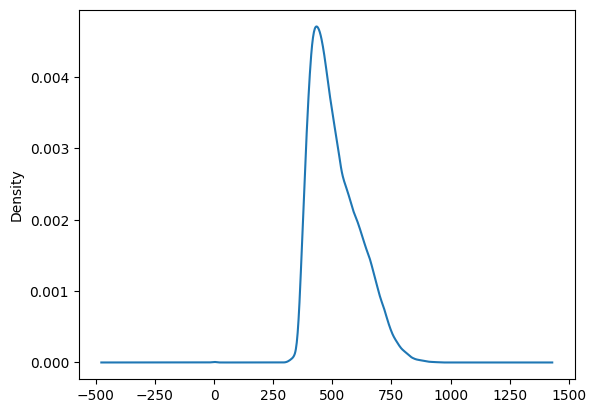

In [ ]:
df.NU_NOTA_MT.plot(kind='kde')

/tmp/ipykernel_3468/2922544828.py:4: FutureWarning: The provided callable <function mean at 0x7a03bf717f60> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg({'NU_NOTA_MT':np.mean})


<Axes: title={'center': 'Nota média em matemática por municípios'}, xlabel='Município', ylabel='Média em matemática'>

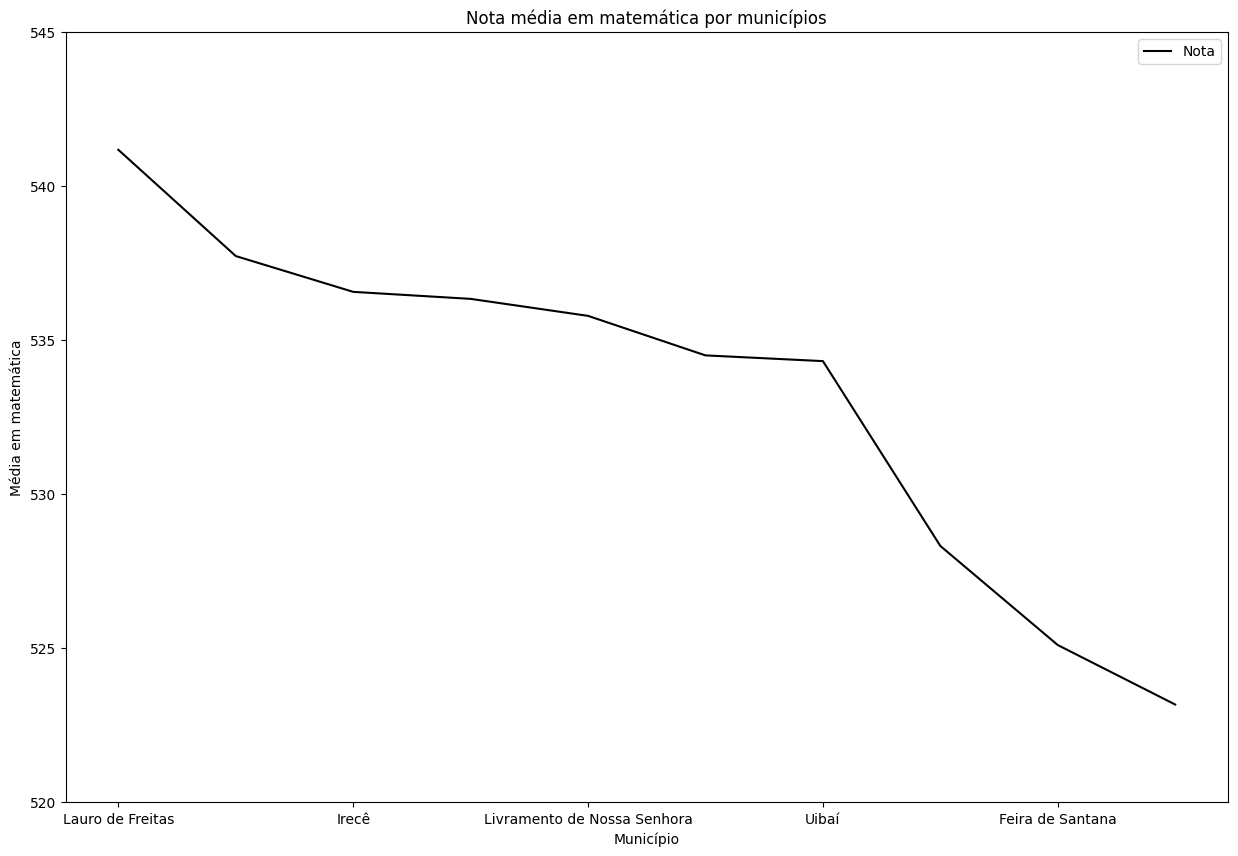

In [ ]:
(
    df.
    groupby(by=['NO_MUNICIPIO_PROVA'])
    .agg({'NU_NOTA_MT':np.mean})
    .reset_index()
    .rename(columns = {'NU_NOTA_MT':'Nota', 'NO_MUNICIPIO_PROVA':'Município'})
    .nlargest(n=10, columns='Nota')
    .plot(
        x = 'Município',
        y = 'Nota',
        figsize = (15, 10),
        color = 'k',
        ylabel = 'Média em matemática',
        title = 'Nota média em matemática por municípios',
        ylim = [520, 545]
    )
)

Ordenação

Em alguns casos precisamos ordenar os dados por alguma coluna ou conjunto de colunas. No Pandas podemos utilizar a função `.sort_values()`.

In [ ]:
provas = df.columns[(df.columns.str.contains('NOTA')) & (~df.columns.str.contains('COMP'))].tolist()
idCandidato = ['NU_INSCRICAO']

In [ ]:
df_subset = df[idCandidato+provas].sample(n=10, random_state = 9999)

In [ ]:
#Ordena o dataset emordm descrecente
df_subset.sort_values(by=['NU_NOTA_MT'], ascending=False)

,NU_INSCRICAO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
227398,210051715408,590.7,665.7,559.3,729.0,720.0
124717,210053777121,601.0,500.9,469.7,582.6,860.0
171946,210051590720,480.9,539.5,544.2,582.4,740.0
168634,210054247453,536.5,564.3,491.4,493.1,0.0
451,210053811122,396.0,427.9,469.9,460.8,360.0
212050,210052725187,361.3,395.5,433.9,427.3,380.0
53444,210051472302,435.4,553.1,432.1,424.8,640.0
171654,210051356897,468.6,500.2,422.8,354.5,380.0
255118,210053165833,NaN,NaN,NaN,NaN,NaN
57913,210053712582,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Ordena o dataset em ordem crescente
df_subset.sort_values(by=['NU_NOTA_MT'], ascending=True)

,NU_INSCRICAO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
171654,210051356897,468.6,500.2,422.8,354.5,380.0
53444,210051472302,435.4,553.1,432.1,424.8,640.0
212050,210052725187,361.3,395.5,433.9,427.3,380.0
451,210053811122,396.0,427.9,469.9,460.8,360.0
168634,210054247453,536.5,564.3,491.4,493.1,0.0
171946,210051590720,480.9,539.5,544.2,582.4,740.0
124717,210053777121,601.0,500.9,469.7,582.6,860.0
227398,210051715408,590.7,665.7,559.3,729.0,720.0
255118,210053165833,NaN,NaN,NaN,NaN,NaN
57913,210053712582,NaN,NaN,NaN,NaN,NaN


Podemos definir onde queremos inserir os valores ausentes com `na_position`.

In [ ]:
df_subset.sort_values(by=['NU_NOTA_MT'], na_position='first', ascending=False)

,NU_INSCRICAO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
255118,210053165833,NaN,NaN,NaN,NaN,NaN
57913,210053712582,NaN,NaN,NaN,NaN,NaN
227398,210051715408,590.7,665.7,559.3,729.0,720.0
124717,210053777121,601.0,500.9,469.7,582.6,860.0
171946,210051590720,480.9,539.5,544.2,582.4,740.0
168634,210054247453,536.5,564.3,491.4,493.1,0.0
451,210053811122,396.0,427.9,469.9,460.8,360.0
212050,210052725187,361.3,395.5,433.9,427.3,380.0
53444,210051472302,435.4,553.1,432.1,424.8,640.0
171654,210051356897,468.6,500.2,422.8,354.5,380.0


Podemos efetuar a ordenação por mais de uma coluna:

In [ ]:
df_subset.sort_values(by=['NU_NOTA_MT', 'NU_NOTA_CH'], ascending=[False, False])

,NU_INSCRICAO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
227398,210051715408,590.7,665.7,559.3,729.0,720.0
124717,210053777121,601.0,500.9,469.7,582.6,860.0
171946,210051590720,480.9,539.5,544.2,582.4,740.0
168634,210054247453,536.5,564.3,491.4,493.1,0.0
451,210053811122,396.0,427.9,469.9,460.8,360.0
212050,210052725187,361.3,395.5,433.9,427.3,380.0
53444,210051472302,435.4,553.1,432.1,424.8,640.0
171654,210051356897,468.6,500.2,422.8,354.5,380.0
255118,210053165833,NaN,NaN,NaN,NaN,NaN
57913,210053712582,NaN,NaN,NaN,NaN,NaN


Podemos ainda aplicar a função `.sort_values()` para uma Séries, neste caso não precisamos especificar o argumento `by`:

In [ ]:
df_subset.NU_NOTA_MT.sort_values()

,NU_NOTA_MT
171654,354.5
53444,424.8
212050,427.3
451,460.8
168634,493.1
171946,582.4
124717,582.6
227398,729.0
255118,NaN
57913,NaN


In [ ]:
df_subset.NU_NOTA_MT.sort_values(ascending=True, na_position='first')

,NU_NOTA_MT
255118,NaN
57913,NaN
171654,354.5
53444,424.8
212050,427.3
451,460.8
168634,493.1
171946,582.4
124717,582.6
227398,729.0


In [ ]:
df_subset

,NU_INSCRICAO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
171654,210051356897,468.6,500.2,422.8,354.5,380.0
255118,210053165833,NaN,NaN,NaN,NaN,NaN
168634,210054247453,536.5,564.3,491.4,493.1,0.0
171946,210051590720,480.9,539.5,544.2,582.4,740.0
212050,210052725187,361.3,395.5,433.9,427.3,380.0
227398,210051715408,590.7,665.7,559.3,729.0,720.0
57913,210053712582,NaN,NaN,NaN,NaN,NaN
451,210053811122,396.0,427.9,469.9,460.8,360.0
124717,210053777121,601.0,500.9,469.7,582.6,860.0
53444,210051472302,435.4,553.1,432.1,424.8,640.0


In [ ]:
df_subset.sort_values(by = ['NU_NOTA_MT'], ascending=False).iloc[:10, :]

,NU_INSCRICAO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
227398,210051715408,590.7,665.7,559.3,729.0,720.0
124717,210053777121,601.0,500.9,469.7,582.6,860.0
171946,210051590720,480.9,539.5,544.2,582.4,740.0
168634,210054247453,536.5,564.3,491.4,493.1,0.0
451,210053811122,396.0,427.9,469.9,460.8,360.0
212050,210052725187,361.3,395.5,433.9,427.3,380.0
53444,210051472302,435.4,553.1,432.1,424.8,640.0
171654,210051356897,468.6,500.2,422.8,354.5,380.0
255118,210053165833,NaN,NaN,NaN,NaN,NaN
57913,210053712582,NaN,NaN,NaN,NaN,NaN


Em alguns casos estamos interessados em criar um ranking. Vamos filtrar a base para os candidatos que fizeram a prova em Salvador e posteriormente criar um top 10 na prova de matemática.

In [ ]:
#df_subset = df.query('NO_MUNICIPIO_PROVA == "Salvador"')[idCandidato]
#df_subset

In [ ]:
df_subset.nlargest(n=10, columns='NU_NOTA_MT')

,NU_INSCRICAO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
227398,210051715408,590.7,665.7,559.3,729.0,720.0
124717,210053777121,601.0,500.9,469.7,582.6,860.0
171946,210051590720,480.9,539.5,544.2,582.4,740.0
168634,210054247453,536.5,564.3,491.4,493.1,0.0
451,210053811122,396.0,427.9,469.9,460.8,360.0
212050,210052725187,361.3,395.5,433.9,427.3,380.0
53444,210051472302,435.4,553.1,432.1,424.8,640.0
171654,210051356897,468.6,500.2,422.8,354.5,380.0
255118,210053165833,NaN,NaN,NaN,NaN,NaN
57913,210053712582,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_subset.nsmallest(n=10, columns=['NU_NOTA_MT', 'NU_NOTA_CH'], keep='first')

,NU_INSCRICAO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
171654,210051356897,468.6,500.2,422.8,354.5,380.0
53444,210051472302,435.4,553.1,432.1,424.8,640.0
212050,210052725187,361.3,395.5,433.9,427.3,380.0
451,210053811122,396.0,427.9,469.9,460.8,360.0
168634,210054247453,536.5,564.3,491.4,493.1,0.0
171946,210051590720,480.9,539.5,544.2,582.4,740.0
124717,210053777121,601.0,500.9,469.7,582.6,860.0
227398,210051715408,590.7,665.7,559.3,729.0,720.0
255118,210053165833,NaN,NaN,NaN,NaN,NaN
57913,210053712582,NaN,NaN,NaN,NaN,NaN


Caso houvesse duplicidade poderíamos passar o argumento keep

- keep = first: pega a primeira ocorrência
- keep = last: pega a última ocorrência
- keep = all: não apaga nenhuma duplicata, mesmo que signifique selecionar mais que n itens  

In [ ]:
df_subset.nlargest(n=10, columns=['NU_NOTA_MT', 'NU_NOTA_CH'], keep='first')

,NU_INSCRICAO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
227398,210051715408,590.7,665.7,559.3,729.0,720.0
124717,210053777121,601.0,500.9,469.7,582.6,860.0
171946,210051590720,480.9,539.5,544.2,582.4,740.0
168634,210054247453,536.5,564.3,491.4,493.1,0.0
451,210053811122,396.0,427.9,469.9,460.8,360.0
212050,210052725187,361.3,395.5,433.9,427.3,380.0
53444,210051472302,435.4,553.1,432.1,424.8,640.0
171654,210051356897,468.6,500.2,422.8,354.5,380.0
255118,210053165833,NaN,NaN,NaN,NaN,NaN
57913,210053712582,NaN,NaN,NaN,NaN,NaN


Índice

A indexação do Pandas conta as linhas e colunas a partir de zero, mas podemos alterar o índice default do DataFrame e ainda ordenar um DataFrame de acordo com seu índice. Em Séries temporais o índice default pode facilitar o trabalho de filtro de datas.

- `.set_index()`

In [ ]:
df_subset.set_index('NU_INSCRICAO', inplace=True)
df_subset.head(3)

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
NU_INSCRICAO,,,,,
210051356897,468.6,500.2,422.8,354.5,380.0
210053165833,NaN,NaN,NaN,NaN,NaN
210054247453,536.5,564.3,491.4,493.1,0.0


- `.sort_index()` : ordena o dataset de acordo com o índice

In [ ]:
df_subset.sort_index().head(3)

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
NU_INSCRICAO,,,,,
210051356897,468.6,500.2,422.8,354.5,380.0
210051472302,435.4,553.1,432.1,424.8,640.0
210051590720,480.9,539.5,544.2,582.4,740.0


Podemos escolher mais de uma coluna como índice do DataFrame, com efeito criamos um multindex

In [ ]:
df_test = df.copy().sample(10)
df_test = df_test.set_index(['NO_MUNICIPIO_PROVA', 'TP_SEXO'])
df_test

,,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
NO_MUNICIPIO_PROVA,TP_SEXO,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Alagoinhas,F,210051367230,2021,5,1,3,1,2,0,2,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2900702,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gandu,M,210054068194,2021,12,0,3,1,1,15,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2911204,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,367.0,481.4,366.5,401.1,EEAEDEEEADDBCAECBBBCCAAABBCCCDAAABBBEEEECCABB,AABCCAAABAE.EACABBEEAAAEDBBDEEBCCBBAADDDDBBBE,99999EEAEACDABCCBBCCAAEECBBBDADADACCCCCDDEEAAB...,DDBBBDEEEAAACCCBBBDDDDBBCCCDDDAAAAEEBBBDDEEEA,1,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,120.0,160.0,120.0,120.0,160.0,680.0
Barreiras,F,210052829715,2021,15,3,1,1,1,15,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2903201,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Caetité,F,210054167210,2021,9,1,3,1,1,0,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2905206,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,425.7,448.7,458.5,460.6,CBEACDABACADBEDBECADACDECDDCDBCCDCCDBBDCDABDC,BEBBDCEACDEBAEACBAEABBCACCADCABEBEECBACCADBAD,EADEC99999ABEBEADCBDDEABCDCEBDEEACBADCBDADBDEB...,EEDCDDCEABDABEABCDDECAACBEDCEEDCCDECEDAECBDDB,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,1.0,120.0,120.0,120.0,100.0,20.0,480.0
Camaçari,F,210053596377,2021,2,1,3,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2905701,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Guanambi,F,210054125502,2021,4,1,1,1,2,0,2,1.0,0,2911709.0,Guanambi,29.0,BA,1.0,2.0,1.0,2911709,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,618.6,568.3,579.9,636.2,ACCACDDDBACDECACEBEADBCEADAADBCDEDEACBABEEEAE,BEDBDCDBACDDEBBBDECABDCBCCEADEDBCEADBCBBAEAAA,CA*AD99999EDADEAEEDDBEEDDABBEEEECCCADCABBABAEC...,BDCABDAEEBDCACBEDDAADABCAABCDBEBACEECBEBDBCCA,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABEDEDE,BADCBADBCEDDEBBADBCABEECCAEABEBAAECBBABAAEEBB,CAABBCAEAABDCDEADCEDBEDDDABBBBDEBCEADABDBACACD...,DDCABDCCAEDCEBBDBDAEEBADCAECDBCCCCDDCEEBABXEE,1.0,160.0,200.0,180.0,180.0,200.0,920.0
Itaberaba,F,210051629429,2021,5,1,2,1,1,2,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2914703,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,411.7,424.5,463.7,448.1,EAABDECBCBEBDCCEABAAEEDBCEADBEACEBBDEDBABCCAD,AABBDAACDDCAADABCEAAEBDAEAEBBEAABEEDBBBACABEA,99999AAEBCBEDDCAEDAADAAEBACACAECCEADCEEABABAED...,BBCCAEBECABADBEACECDACADAEBBBCADEACBEDCBBECEA,1,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,120.0,140.0,100.0,120.0,80.0,560.0
Salvador,M,210051773884,2021,11,1,3,1,1,9,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927408,29,BA,1,1,1,1,910.0,879.0,889.0,900.0,587.4,731.9,637.8,763.6,AAEDCCDABBEDCBDCDBBAABBEADDEEEBBEABACDBBEEBCD,BADCDAABCEDDEBBADBCABEECCAEABEBAAAEBBABAAEEDB,CAAAC99999BDDDEADEEDBEDDEABBEEBABCBACAADDACDCD...,DCCDBDCCACBDCCBDADAEAADDCADCDBCCCCDDCEEBABEAE,0,ADCDCDBBBECDCCDCBCBDABCAADCBEBABEEBBBCABE

In [ ]:
type(df_test.index)

pandas.core.indexes.multi.MultiIndex

- `.reset_index()` : para retornar ao dataset original

In [ ]:
df_subset = df_subset.reset_index(drop=False)
df_subset.head()

,NU_INSCRICAO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
0,210051356897,468.6,500.2,422.8,354.5,380.0
1,210053165833,NaN,NaN,NaN,NaN,NaN
2,210054247453,536.5,564.3,491.4,493.1,0.0
3,210051590720,480.9,539.5,544.2,582.4,740.0
4,210052725187,361.3,395.5,433.9,427.3,380.0


Agregação/Sumarização

Nesta seção vamos aprender a aplicar medidas para sumerizar dados, tais como soma, contagem, média, etc.

Em geral, para aplicar uma função de agregação em uma coluna a sintaxe será:

`df.column.agg_function()`

In [ ]:
#Média na nota de matemática por gênero
subset_tp_sexo_m = df.query('TP_SEXO == "M"')
subset_tp_sexo_f = df.query('TP_SEXO == "F"')

Agregação:
- `df.column.agg_func()`

In [ ]:
#Nota máxima do gênero masculino
subset_tp_sexo_m.NU_NOTA_MT.max()

953.1

In [ ]:
#Nota máxima do gênero feminino
subset_tp_sexo_f.NU_NOTA_MT.max()

944.1

In [ ]:
#Nota média do gênero masculino
subset_tp_sexo_m.NU_NOTA_MT.mean()

np.float64(538.500684898471)

In [ ]:
#Nota média do gênero feminino
subset_tp_sexo_f.NU_NOTA_MT.mean()

np.float64(499.7702519508294)

In [ ]:
#Nota mediana do gênero masculino
subset_tp_sexo_m.NU_NOTA_MT.median()

522.0

In [ ]:
#Nota mediana do gênero feminino
subset_tp_sexo_f.NU_NOTA_MT.median()

478.2

In [ ]:
provas = df.columns[(df.columns.str.contains('NOTA')) & (~df.columns.str.contains('COMP'))].tolist()
idCandidato = ['NU_INSCRICAO']

In [ ]:
subset_tp_sexo_m[provas].agg([np.min, np.max, np.mean, np.median]).T.round(2)

/tmp/ipykernel_3468/1992171871.py:1: FutureWarning: The provided callable <function min at 0x7a03bf7176a0> is currently using Series.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  subset_tp_sexo_m[provas].agg([np.min, np.max, np.mean, np.median]).T.round(2)
/tmp/ipykernel_3468/1992171871.py:1: FutureWarning: The provided callable <function max at 0x7a03bf717560> is currently using Series.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  subset_tp_sexo_m[provas].agg([np.min, np.max, np.mean, np.median]).T.round(2)
/tmp/ipykernel_3468/1992171871.py:1: FutureWarning: The provided callable <function mean at 0x7a03bf717f60> is currently using Series.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  subset_tp_sexo_m[provas].

,min,max,mean,median
NU_NOTA_CN,0.0,839.0,495.43,488.80
NU_NOTA_CH,0.0,846.9,519.71,523.00
NU_NOTA_LC,0.0,773.5,496.80,499.75
NU_NOTA_MT,0.0,953.1,538.50,522.00
NU_NOTA_REDACAO,0.0,980.0,592.53,600.00


In [ ]:
subset_tp_sexo_f[provas].agg([np.min, np.max, np.mean, np.median]).T.round(2)

/tmp/ipykernel_3468/4019581125.py:1: FutureWarning: The provided callable <function min at 0x7a03bf7176a0> is currently using Series.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  subset_tp_sexo_f[provas].agg([np.min, np.max, np.mean, np.median]).T.round(2)
/tmp/ipykernel_3468/4019581125.py:1: FutureWarning: The provided callable <function max at 0x7a03bf717560> is currently using Series.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  subset_tp_sexo_f[provas].agg([np.min, np.max, np.mean, np.median]).T.round(2)
/tmp/ipykernel_3468/4019581125.py:1: FutureWarning: The provided callable <function mean at 0x7a03bf717f60> is currently using Series.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  subset_tp_sexo_f[provas].

,min,max,mean,median
NU_NOTA_CN,0.0,819.4,471.42,462.2
NU_NOTA_CH,0.0,832.5,498.83,493.4
NU_NOTA_LC,0.0,821.6,484.92,485.2
NU_NOTA_MT,0.0,944.1,499.77,478.2
NU_NOTA_REDACAO,0.0,1000.0,613.83,600.0


In [ ]:
#Qual o aluno que tirou a nota máxima/mínima
df.NU_NOTA_MT.max()

953.1

In [ ]:
df.NU_NOTA_MT.idxmax()

55177

In [ ]:
df.iloc[55177,]

,55177
NU_INSCRICAO,210053912306
NU_ANO,2021
TP_FAIXA_ETARIA,2
TP_SEXO,M
TP_ESTADO_CIVIL,1
TP_COR_RACA,3
TP_NACIONALIDADE,1
TP_ST_CONCLUSAO,2
TP_ANO_CONCLUIU,0
TP_ESCOLA,3


In [ ]:
df.iloc[df.NU_NOTA_MT.idxmax(), ]

,55177
NU_INSCRICAO,210053912306
NU_ANO,2021
TP_FAIXA_ETARIA,2
TP_SEXO,M
TP_ESTADO_CIVIL,1
TP_COR_RACA,3
TP_NACIONALIDADE,1
TP_ST_CONCLUSAO,2
TP_ANO_CONCLUIU,0
TP_ESCOLA,3


In [ ]:
#Nota mínima em redação
df[df.NU_NOTA_REDACAO != 0].NU_NOTA_REDACAO

,NU_NOTA_REDACAO
0,380.0
1,NaN
2,460.0
3,580.0
4,540.0
...,...
266189,NaN
266190,NaN
266191,NaN
266192,NaN


In [ ]:
mask_1 = df.NU_NOTA_REDACAO.notna()
mask_2 = df.NU_NOTA_REDACAO != 0

In [ ]:
subset = df[(mask_1) & (mask_2)]

<Axes: >

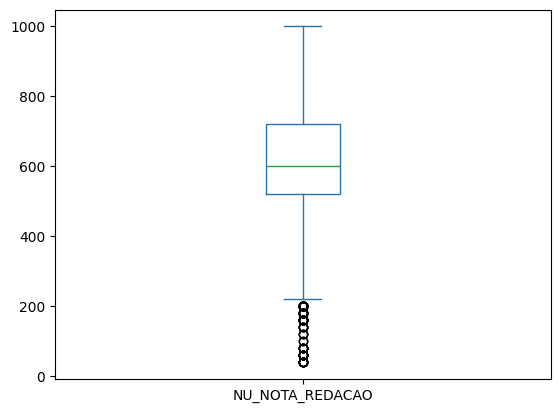

In [ ]:
subset.NU_NOTA_REDACAO.plot(kind='box')

In [ ]:
subset.NU_NOTA_REDACAO.agg([np.min, np.max, np.mean, np.median]).round(2)

/tmp/ipykernel_3468/2724154102.py:1: FutureWarning: The provided callable <function min at 0x7a03bf7176a0> is currently using Series.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  subset.NU_NOTA_REDACAO.agg([np.min, np.max, np.mean, np.median]).round(2)
/tmp/ipykernel_3468/2724154102.py:1: FutureWarning: The provided callable <function max at 0x7a03bf717560> is currently using Series.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  subset.NU_NOTA_REDACAO.agg([np.min, np.max, np.mean, np.median]).round(2)
/tmp/ipykernel_3468/2724154102.py:1: FutureWarning: The provided callable <function mean at 0x7a03bf717f60> is currently using Series.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  subset.NU_NOTA_REDACAO.agg([np.mi

,NU_NOTA_REDACAO
min,40.00
max,1000.00
mean,625.94
median,600.00


In [ ]:
#média das colunas
df[provas].mean().round(2) #df[provas].mean(axis=0)

,0
NU_NOTA_CN,479.94
NU_NOTA_CH,506.23
NU_NOTA_LC,489.13
NU_NOTA_MT,513.51
NU_NOTA_REDACAO,606.28


In [ ]:
#Média dos alunos
df[provas].mean(axis=1)

,0
0,466.94
1,NaN
2,447.88
3,562.10
4,544.00
...,...
266189,NaN
266190,NaN
266191,NaN
266192,NaN


missing

- `fillna()`

In [ ]:
#missing simbólico
df[provas].mean(axis=1).fillna(-1)

,0
0,466.94
1,-1.00
2,447.88
3,562.10
4,544.00
...,...
266189,-1.00
266190,-1.00
266191,-1.00
266192,-1.00


In [ ]:
df_copy = df.copy()
df_copy['MEAN'] = df[provas].mean(axis=1)
df_copy.head(3)

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,MEAN
0,210051128744,2021,4,F,1,3,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2927200,Ruy Barbosa,29,BA,1,1,1,1,909.0,881.0,892.0,899.0,507.6,539.2,494.6,413.3,BAEDEBDECCEAEDDCBDEDAEECEEEDBDECBDCECBCCDABED,EEEBAABCBCDBEAEBEACEDDEDECACBDBCDACECDAECBCBD,99999ACAEEEEBDEACDACDEABCEABBDEDBAEEBDEEACDBAC...,BACEACDACBAAAEDCECABBACDCDBBA.CEABCDADADBECBE,1,EDECABEDABCBEBACCDCBBEEBBCBDAAECDCBDCDBBBADCD,BEECCAEABADBCAEBAAEEDDEBBBADBCBAAEEBBBADCCBBA,ABBACAAECACDBDDADEBDDCBDCEDBEDDBBBBDCEEAADABAC...,EEXEBABDDCECCBCCECDCAEBADEABBDBDEDCEDCCADDCAB,1.0,80.0,120.0,80.0,80.0,20.0,380.0,466.94
1,210054173438,2021,5,F,1,2,1,2,0,2,1.0,0,2927408.0,Salvador,29.0,BA,1.0,1.0,1.0,2927408,Salvador,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,210052118573,2021,3,F,1,3,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2903201,Barreiras,29,BA,1,1,1,1,912.0,882.0,891.0,901.0,439.6,437.7,455.9,446.2,BCEDEACAEDCEDCBDDCCAADABADDEBEECBACDCCABBDCCA,AAEADCDCAAADCBBBAABBEAEDABCDAACDDCBDAAABAABBB,EDBEC99999DDAAEBBDCDBBAABDECAADAEACCDABCEABABE...,EBBEBDCCDDCDCBADABBBCCEABDADCBCCACBDACDCDADCE,0,DABCEDEBEEBBCABEDDCBCBECDADCDAACBDCCCDBBBEBAB,EBAAEADBCACBBABEECBAAEEBBBADCBADBCEDDEBBCAEAB,ACABBACAEADCEADABDACDCEABDDADBEDDDEBBACCDDDCCE...,DCCAEBABDDCABEECCBCCEXADDCEECDEBADCABBDBDEDCE,1.0,80.0,120.0,80.0,100.0,80.0,460.0,447.88


In [ ]:
df_copy.MEAN.fillna(-1)

,MEAN
0,466.94
1,-1.00
2,447.88
3,562.10
4,544.00
...,...
266189,-1.00
266190,-1.00
266191,-1.00
266192,-1.00


In [ ]:
#Qual a proporção entre gênero
df.TP_SEXO.value_counts()

,count
TP_SEXO,
F,171997
M,94197


In [ ]:
df.groupby(by=['TP_SEXO'])['NU_INSCRICAO'].count()

,NU_INSCRICAO
TP_SEXO,
F,171997
M,94197


In [ ]:
df.groupby(by=['TP_SEXO', 'TP_ESCOLA'])['NU_INSCRICAO'].count()

TP_SEXO  TP_ESCOLA
F        1            114715
         2             50561
         3              6721
M        1             62455
         2             26423
         3              5319
Name: NU_INSCRICAO, dtype: int64

In [ ]:
#Qual a distribuição de frequência dos alunos por tipo de escola
df.groupby(by=['TP_ESCOLA'])['NU_INSCRICAO'].count()

,NU_INSCRICAO
TP_ESCOLA,
1,177170
2,76984
3,12040


In [ ]:
#Qual o desempenh em matemática por tipo de escola
df.groupby(by=['TP_ESCOLA'])['NU_NOTA_MT'].mean().round(2)

,NU_NOTA_MT
TP_ESCOLA,
1,519.02
2,487.38
3,579.83


In [ ]:
df.groupby(by=['TP_ESCOLA'])[['NU_NOTA_MT', 'NU_NOTA_CN']].agg([np.min, np.median, np.mean, np.std, np.max]).round(2)

/tmp/ipykernel_3468/4117380496.py:1: FutureWarning: The provided callable <function min at 0x7a03bf7176a0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df.groupby(by=['TP_ESCOLA'])[['NU_NOTA_MT', 'NU_NOTA_CN']].agg([np.min, np.median, np.mean, np.std, np.max]).round(2)
/tmp/ipykernel_3468/4117380496.py:1: FutureWarning: The provided callable <function median at 0x7a03bf1a7380> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  df.groupby(by=['TP_ESCOLA'])[['NU_NOTA_MT', 'NU_NOTA_CN']].agg([np.min, np.median, np.mean, np.std, np.max]).round(2)
/tmp/ipykernel_3468/4117380496.py:1: FutureWarning: The provided callable <function mean at 0x7a03bf717f60> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callab

NU_NOTA_MT                               NU_NOTA_CN                 \
                 min median    mean     std    max        min median    mean   
TP_ESCOLA                                                                      
1                0.0  497.8  519.02  103.69  953.1        0.0  476.5  485.69   
2                0.0  468.9  487.38   83.77  929.8        0.0  451.7  458.42   
3                0.0  581.6  579.83  110.52  953.1      340.1  523.1  522.75   

                         
             std    max  
TP_ESCOLA                
1          76.76  839.0  
2          63.18  819.4  
3          79.61  796.3

In [ ]:
#Nota média por município
df.groupby(by=['NO_MUNICIPIO_PROVA'])['NU_NOTA_MT'].agg([np.min, np.mean, np.median, np.max]).reset_index(drop=False).sort_values(by=['max', 'mean', 'median'], ascending=False).round(2)

/tmp/ipykernel_3468/298621376.py:2: FutureWarning: The provided callable <function min at 0x7a03bf7176a0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df.groupby(by=['NO_MUNICIPIO_PROVA'])['NU_NOTA_MT'].agg([np.min, np.mean, np.median, np.max]).reset_index(drop=False).sort_values(by=['max', 'mean', 'median'], ascending=False).round(2)
/tmp/ipykernel_3468/298621376.py:2: FutureWarning: The provided callable <function mean at 0x7a03bf717f60> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.groupby(by=['NO_MUNICIPIO_PROVA'])['NU_NOTA_MT'].agg([np.min, np.mean, np.median, np.max]).reset_index(drop=False).sort_values(by=['max', 'mean', 'median'], ascending=False).round(2)
/tmp/ipykernel_3468/298621376.py:2: FutureWarning: The provided calla

,NO_MUNICIPIO_PROVA,min,mean,median,max
160,Vitória da Conquista,0.0,536.34,517.30,953.1
125,Salvador,0.0,534.51,515.60,953.1
9,Barreiras,318.8,517.59,496.80,948.8
51,Feira de Santana,316.0,525.10,502.90,948.5
139,Serrinha,346.8,501.14,479.85,948.5
...,...,...,...,...,...
27,Cansanção,360.9,475.03,459.20,726.9
103,Oliveira dos Brejinhos,380.6,505.67,488.10,707.2
136,Sento Sé,367.8,476.35,462.30,702.3
154,Umburanas,357.6,464.58,453.50,686.9


In [ ]:
df_visao_municipio = (df.query('NU_NOTA_MT != 0').groupby(by=['NO_MUNICIPIO_PROVA', 'CO_MUNICIPIO_PROVA'], as_index = False)['NU_NOTA_MT'].agg([np.min, np.mean, np.median, np.max]).reset_index(drop = False).rename(
    columns = {
        'CO_MUNICIPIO_PROVA' : 'COD_IBGE',
        'NO_MUNICIPIO_PROVA' : 'Município',
        'min' : 'Mínimo',
        'mean' : 'Média',
        'median' : 'Mediana',
        'max' : 'Máximo'
    }
).sort_values(by= ['Máximo', 'Média', 'Mediana'], ascending = False).reset_index(drop=True))

/tmp/ipykernel_3468/1155235564.py:1: FutureWarning: The provided callable <function min at 0x7a03bf7176a0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df_visao_municipio = (df.query('NU_NOTA_MT != 0').groupby(by=['NO_MUNICIPIO_PROVA', 'CO_MUNICIPIO_PROVA'], as_index = False)['NU_NOTA_MT'].agg([np.min, np.mean, np.median, np.max]).reset_index(drop = False).rename(
/tmp/ipykernel_3468/1155235564.py:1: FutureWarning: The provided callable <function mean at 0x7a03bf717f60> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_visao_municipio = (df.query('NU_NOTA_MT != 0').groupby(by=['NO_MUNICIPIO_PROVA', 'CO_MUNICIPIO_PROVA'], as_index = False)['NU_NOTA_MT'].agg([np.min, np.mean, np.median, np.max]).reset_index(drop = False).rename(
/tmp/ipyk

In [ ]:
df_visao_municipio

,index,Município,COD_IBGE,Mínimo,Média,Mediana,Máximo
0,160,Vitória da Conquista,2933307,315.5,536.491289,517.30,953.1
1,125,Salvador,2927408,315.3,534.623544,515.60,953.1
2,9,Barreiras,2903201,318.8,517.589528,496.80,948.8
3,51,Feira de Santana,2910800,316.0,525.103365,502.90,948.5
4,139,Serrinha,2930501,346.8,501.138564,479.85,948.5
...,...,...,...,...,...,...,...
157,27,Cansanção,2906808,360.9,475.027413,459.20,726.9
158,103,Oliveira dos Brejinhos,2923209,380.6,505.673239,488.10,707.2
159,136,Sento Sé,2930204,367.8,476.352846,462.30,702.3
160,154,Umburanas,2932457,357.6,464.582090,453.50,686.9


In [ ]:
df_quant_inscritos = (df.groupby(by=['NO_MUNICIPIO_PROVA', 'CO_MUNICIPIO_PROVA'], as_index=False)['NU_INSCRICAO'].count().rename(columns={
    'NO_MUNICIPIO_PROVA	': 'Município',
    'CO_MUNICIPIO_PROVA' : 'COD_IBGE',
    'NU_INSCRICAO' : 'Quant_inscritos'
}).sort_values(by=['Quant_inscritos'], ascending=False). reset_index(drop=True))

In [ ]:
total = df_quant_inscritos.Quant_inscritos.sum()

In [ ]:
df_quant_inscritos['Percent_inscritos'] = (df_quant_inscritos.Quant_inscritos / total *100).round(2)
df_quant_inscritos

,NO_MUNICIPIO_PROVA,COD_IBGE,Quant_inscritos,Percent_inscritos
0,Salvador,2927408,58502,21.98
1,Feira de Santana,2910800,16689,6.27
2,Vitória da Conquista,2933307,10792,4.05
3,Barreiras,2903201,6083,2.29
4,Lauro de Freitas,2919207,5647,2.12
...,...,...,...,...
157,Sento Sé,2930204,200,0.08
158,São Félix,2929008,179,0.07
159,Itanhém,2916005,175,0.07
160,Riachão das Neves,2926202,172,0.06


In [ ]:
df_quant_inscritos['Ano_inscrição'] = 2021
df_quant_inscritos

,NO_MUNICIPIO_PROVA,COD_IBGE,Quant_inscritos,Percent_inscritos,Ano_inscrição
0,Salvador,2927408,58502,21.98,2021
1,Feira de Santana,2910800,16689,6.27,2021
2,Vitória da Conquista,2933307,10792,4.05,2021
3,Barreiras,2903201,6083,2.29,2021
4,Lauro de Freitas,2919207,5647,2.12,2021
...,...,...,...,...,...
157,Sento Sé,2930204,200,0.08,2021
158,São Félix,2929008,179,0.07,2021
159,Itanhém,2916005,175,0.07,2021
160,Riachão das Neves,2926202,172,0.06,2021


In [ ]:
df_municipio = pd.merge(
    df_visao_municipio,
    df_quant_inscritos.drop(columns=['NO_MUNICIPIO_PROVA']),
    on = 'COD_IBGE',
    how = 'inner'
).round(2)

In [ ]:
df_municipio

,index,Município,COD_IBGE,Mínimo,Média,Mediana,Máximo,Quant_inscritos,Percent_inscritos,Ano_inscrição
0,160,Vitória da Conquista,2933307,315.5,536.49,517.30,953.1,10792,4.05,2021
1,125,Salvador,2927408,315.3,534.62,515.60,953.1,58502,21.98,2021
2,9,Barreiras,2903201,318.8,517.59,496.80,948.8,6083,2.29,2021
3,51,Feira de Santana,2910800,316.0,525.10,502.90,948.5,16689,6.27,2021
4,139,Serrinha,2930501,346.8,501.14,479.85,948.5,2802,1.05,2021
...,...,...,...,...,...,...,...,...,...,...
157,27,Cansanção,2906808,360.9,475.03,459.20,726.9,415,0.16,2021
158,103,Oliveira dos Brejinhos,2923209,380.6,505.67,488.10,707.2,209,0.08,2021
159,136,Sento Sé,2930204,367.8,476.35,462.30,702.3,200,0.08,2021
160,154,Umburanas,2932457,357.6,464.58,453.50,686.9,225,0.08,2021
